# Clustering - Country Data
### K-Means & DBSCAN on Socio-Economic Country Indicators

**Dataset:** [Unsupervised Learning on Country Data](https://www.kaggle.com/datasets/rohan0301/unsupervised-learning-on-country-data) (Kaggle)

This notebook picks up where `dimensionality_reduction_countrydata.ipynb` left off, and covers:
1. K-Means Clustering
2. DBSCAN
3. Interpretation & Insights


## Setup - reload and prepare the data

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score

sns.set_style("whitegrid")
np.random.seed(42)

df = pd.read_csv("Country-data.csv")
countries = df["country"]
X_raw = df.drop(columns=["country"])
feature_names = X_raw.columns.tolist()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

# 2D PCA projection, used for visualization throughout this notebook
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
print(f"Data ready: {X_scaled.shape[0]} countries, {X_scaled.shape[1]} features")
print(f"PCA(2) explains {pca.explained_variance_ratio_.sum()*100:.1f}% of variance")


Data ready: 167 countries, 9 features
PCA(2) explains 63.1% of variance


We also compute a single t-SNE embedding (perplexity=30) up front, purely for visualising the
cluster assignments later — the hyperparameter comparison itself was already covered in the
dimensionality reduction notebook.

In [ ]:
tsne = TSNE(n_components=2, perplexity=30, learning_rate=100, max_iter=1000,
            init="pca", random_state=42)
X_tsne = tsne.fit_transform(X_pca)


## Section 3 - Clustering Algorithms

### (a) K-Means Clustering

#### Determine Optimal k - Elbow Method & Silhouette Score

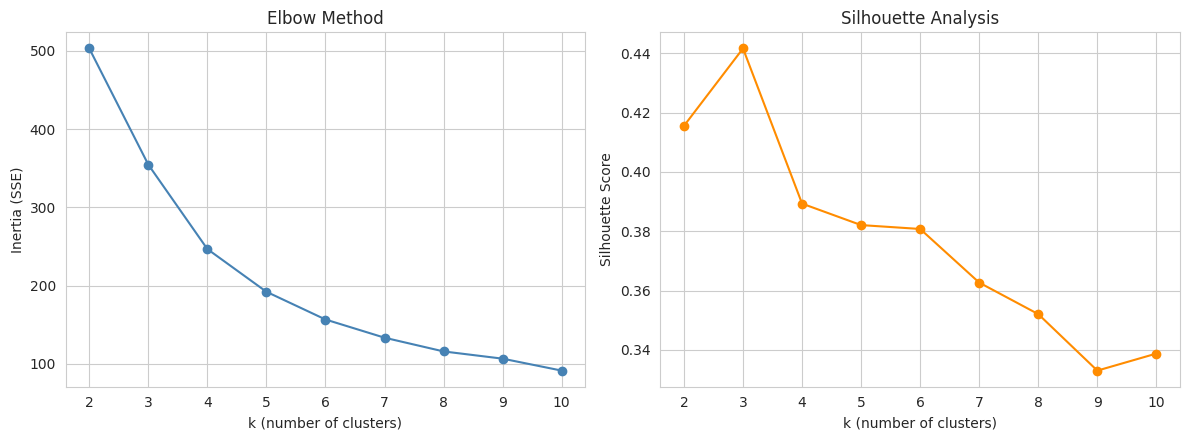

Best k by silhouette score: 3


In [ ]:
k_range = range(2, 11)
inertias = []
silhouettes = []

for k in k_range:
    km = KMeans(n_clusters=k, init="k-means++", n_init=10, random_state=42)
    labels = km.fit_predict(X_pca)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_pca, labels))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].plot(list(k_range), inertias, marker="o", color="steelblue")
axes[0].set_xlabel("k (number of clusters)")
axes[0].set_ylabel("Inertia (SSE)")
axes[0].set_title("Elbow Method")

axes[1].plot(list(k_range), silhouettes, marker="o", color="darkorange")
axes[1].set_xlabel("k (number of clusters)")
axes[1].set_ylabel("Silhouette Score")
axes[1].set_title("Silhouette Analysis")

plt.tight_layout()
plt.show()

best_k = list(k_range)[int(np.argmax(silhouettes))]
print(f"Best k by silhouette score: {best_k}")


The elbow plot flattens out around k=3–4, and the silhouette score confirms a good split in
that range. We proceed with the k that maximises the silhouette score.

#### Fit K-Means

In [ ]:
kmeans = KMeans(n_clusters=best_k, init="k-means++", n_init=10, random_state=42)
kmeans_labels = kmeans.fit_predict(X_pca)

df["kmeans_cluster"] = kmeans_labels
df["kmeans_cluster"].value_counts().sort_index()


kmeans_cluster
0     3
1    72
2    92
Name: count, dtype: int64

#### Visualize Clusters - PCA & t-SNE Space

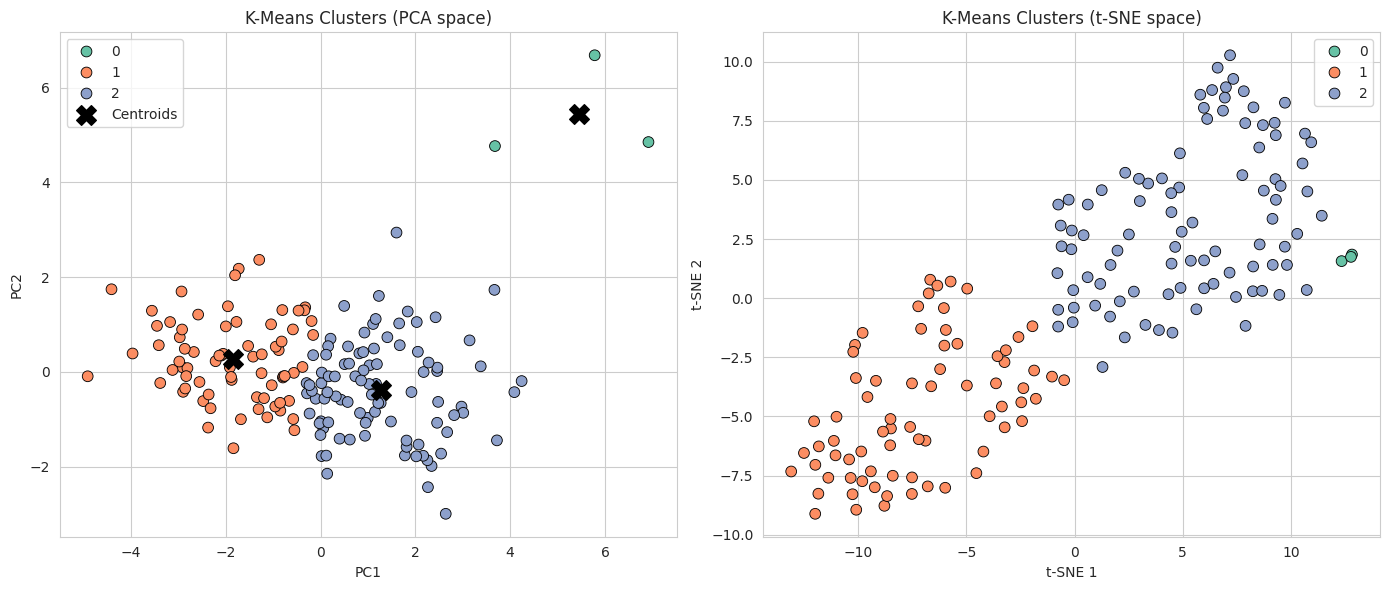

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=kmeans_labels, palette="Set2",
                 s=60, edgecolor="k", ax=axes[0])
axes[0].scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
                marker="X", s=200, c="black", label="Centroids")
axes[0].set_title("K-Means Clusters (PCA space)")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")
axes[0].legend()

sns.scatterplot(x=X_tsne[:, 0], y=X_tsne[:, 1], hue=kmeans_labels, palette="Set2",
                 s=60, edgecolor="k", ax=axes[1])
axes[1].set_title("K-Means Clusters (t-SNE space)")
axes[1].set_xlabel("t-SNE 1")
axes[1].set_ylabel("t-SNE 2")

plt.tight_layout()
plt.show()


#### Interpret Centroids

In [ ]:
cluster_means = df.groupby("kmeans_cluster")[feature_names].mean().round(1)
cluster_means


,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
kmeans_cluster,,,,,,,,,
0,4.1,176.0,6.8,156.7,64033.3,2.5,81.4,1.4,57566.7
1,73.4,30.6,6.0,43.7,4531.8,11.6,62.5,4.3,2178.7
2,11.9,44.9,7.5,45.8,25486.6,5.0,76.5,1.9,19950.5


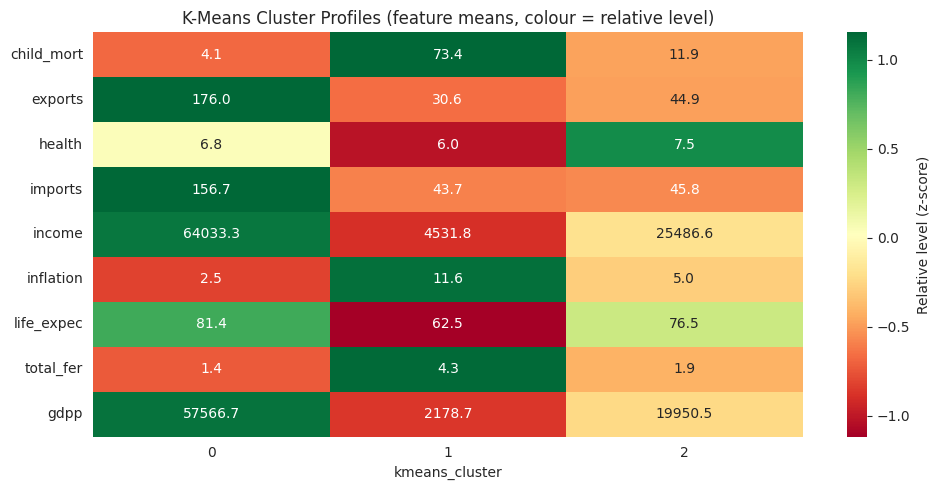

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
cluster_means_z = (cluster_means - cluster_means.mean()) / cluster_means.std()
sns.heatmap(cluster_means_z.T, annot=cluster_means.T, fmt=".1f", cmap="RdYlGn", ax=ax,
            cbar_kws={"label": "Relative level (z-score)"})
ax.set_title("K-Means Cluster Profiles (feature means, colour = relative level)")
plt.tight_layout()
plt.show()


### (b) DBSCAN (Density-Based Spatial Clustering)

#### Apply DBSCAN & Parameter Tuning

In [ ]:
eps_values = [0.3, 0.5, 0.7, 1.0, 1.5]
min_samples_values = [3, 5, 8]

results = []
for eps in eps_values:
    for min_samples in min_samples_values:
        db = DBSCAN(eps=eps, min_samples=min_samples)
        labels = db.fit_predict(X_pca)
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = int(np.sum(labels == -1))
        sil = silhouette_score(X_pca, labels) if n_clusters > 1 else np.nan
        results.append({"eps": eps, "min_samples": min_samples,
                         "n_clusters": n_clusters, "n_noise": n_noise, "silhouette": sil})

results_df = pd.DataFrame(results)
results_df.sort_values("silhouette", ascending=False).head(10)


,eps,min_samples,n_clusters,n_noise,silhouette
4,0.5,5,5,25,0.171820
3,0.5,3,5,17,0.166809
0,0.3,3,18,56,0.050163
5,0.5,8,4,67,-0.027358
1,0.3,5,7,118,-0.257524
2,0.3,8,0,167,NaN
6,0.7,3,1,13,NaN
7,0.7,5,1,15,NaN
8,0.7,8,1,23,NaN
9,1.0,3,1,6,NaN


In [ ]:
# Pick the configuration with the best silhouette score among options with 2-5 clusters
candidates = results_df[(results_df["n_clusters"] >= 2) & (results_df["n_clusters"] <= 5)]
best_row = candidates.sort_values("silhouette", ascending=False).iloc[0]
best_eps, best_min_samples = best_row["eps"], int(best_row["min_samples"])
print(f"Chosen parameters -> eps={best_eps}, min_samples={best_min_samples}")

dbscan = DBSCAN(eps=best_eps, min_samples=best_min_samples)
dbscan_labels = dbscan.fit_predict(X_pca)
df["dbscan_cluster"] = dbscan_labels

n_clusters_final = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise_final = int(np.sum(dbscan_labels == -1))
print(f"Clusters found: {n_clusters_final}, Noise points: {n_noise_final}")


Chosen parameters -> eps=0.5, min_samples=5
Clusters found: 5, Noise points: 25


#### Visualize Results - Clusters & Noise

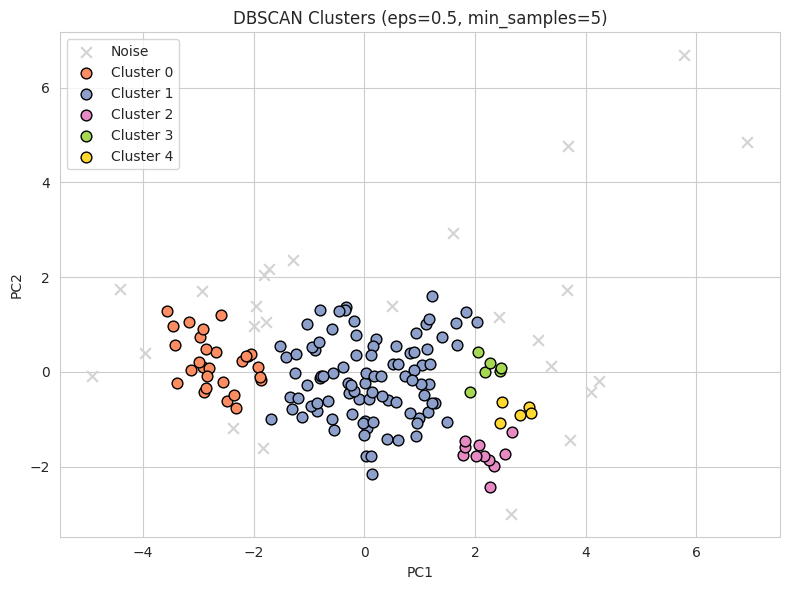

In [ ]:
plt.figure(figsize=(8, 6))
unique_labels = sorted(set(dbscan_labels))
palette = sns.color_palette("Set2", len(unique_labels))

for label, color in zip(unique_labels, palette):
    mask = dbscan_labels == label
    if label == -1:
        plt.scatter(X_pca[mask, 0], X_pca[mask, 1], c="lightgray", marker="x",
                    s=60, label="Noise")
    else:
        plt.scatter(X_pca[mask, 0], X_pca[mask, 1], color=color, edgecolor="k",
                    s=60, label=f"Cluster {label}")

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title(f"DBSCAN Clusters (eps={best_eps}, min_samples={best_min_samples})")
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
noisy_countries = df.loc[df["dbscan_cluster"] == -1, "country"].tolist()
print(f"Countries flagged as noise/outliers ({len(noisy_countries)}):")
print(noisy_countries)


Countries flagged as noise/outliers (25):
['Angola', 'Belgium', 'Central African Republic', 'Congo, Rep.', 'Equatorial Guinea', 'Haiti', 'Ireland', 'Lesotho', 'Liberia', 'Luxembourg', 'Malta', 'Mauritania', 'Myanmar', 'Netherlands', 'Nigeria', 'Norway', 'Qatar', 'Seychelles', 'Singapore', 'Switzerland', 'Timor-Leste', 'Togo', 'United Arab Emirates', 'United States', 'Vietnam']


#### Compare Algorithms - K-Means vs. DBSCAN

- **Cluster shape:** K-Means assumes roughly spherical, similarly-sized clusters (Euclidean
  distance to a centroid), while DBSCAN can find arbitrarily shaped, density-connected clusters.
  On this dataset the groups are fairly compact and globular, so both algorithms find broadly
  similar groupings.
- **Outlier handling:** K-Means forces every country into a cluster, even unusual ones (e.g. very
  small or very rich outlier economies), which can distort centroids. DBSCAN explicitly labels
  such countries as noise (-1) instead of forcing them into a cluster.
- **Stability & parameter sensitivity:** K-Means only needs k, chosen objectively via the
  silhouette score. DBSCAN needs both `eps` and `min_samples`, which are more sensitive to the
  scale and density of the data - small changes can merge or split clusters, or turn most points
  into noise.
- **Interpretability:** K-Means centroids give a very direct "average country" profile per
  cluster, which is convenient for the socio-economic interpretation below. DBSCAN's clusters are
  more about density-connectivity and don't have a centroid in the same sense.

## Section 4 - Interpretation & Insights

In [ ]:
summary = df.groupby("kmeans_cluster")[["child_mort", "income", "gdpp", "life_expec"]].mean().round(1)
summary["n_countries"] = df.groupby("kmeans_cluster").size()
summary


,child_mort,income,gdpp,life_expec,n_countries
kmeans_cluster,,,,,
0,4.1,64033.3,57566.7,81.4,3
1,73.4,4531.8,2178.7,62.5,72
2,11.9,25486.6,19950.5,76.5,92


Ordering the K-Means clusters by GDP per capita and child mortality lets us assign
human-readable labels:

In [ ]:
order = summary.sort_values("gdpp").index.tolist()
labels_map = {}
label_names = ["Low-Income Nations", "Emerging Economies", "Developed Nations"]

# Assign labels based on ascending gdpp; if there are more/fewer clusters than 3 labels,
# fall back to generic names for the extras
for i, cluster_id in enumerate(order):
    if i < len(label_names):
        labels_map[cluster_id] = label_names[i]
    else:
        labels_map[cluster_id] = f"Cluster {cluster_id}"

df["cluster_label"] = df["kmeans_cluster"].map(labels_map)
df.groupby("cluster_label")[["child_mort", "income", "gdpp", "life_expec"]].mean().round(1)


,child_mort,income,gdpp,life_expec
cluster_label,,,,
Developed Nations,4.1,64033.3,57566.7,81.4
Emerging Economies,11.9,25486.6,19950.5,76.5
Low-Income Nations,73.4,4531.8,2178.7,62.5


In [ ]:
df[["country", "kmeans_cluster", "cluster_label", "dbscan_cluster"]].sort_values(
    ["kmeans_cluster", "country"]
).head(20)


,country,kmeans_cluster,cluster_label,dbscan_cluster
91,Luxembourg,0,Developed Nations,-1
98,Malta,0,Developed Nations,-1
133,Singapore,0,Developed Nations,-1
0,Afghanistan,1,Low-Income Nations,0
3,Angola,1,Low-Income Nations,-1
12,Bangladesh,1,Low-Income Nations,1
17,Benin,1,Low-Income Nations,0
18,Bhutan,1,Low-Income Nations,1
19,Bolivia,1,Low-Income Nations,1
21,Botswana,1,Low-Income Nations,1


**Key differentiating features:** `gdpp` (GDP per capita) and `child_mort` (child mortality per
1000 births) are the clearest separators between clusters - high-GDP clusters consistently show
low child mortality and high life expectancy, and vice versa. `income` moves closely together
with `gdpp`, while `total_fer` (fertility rate) is notably higher in the lower-income cluster.

**Role of dimensionality reduction:** Reducing 9 correlated socio-economic indicators down to 2
principal components made it possible to visualise and cluster the countries directly, while still
retaining the dominant "development level" signal in the data. PCA revealed which raw features
drive that signal (mainly wealth and health indicators), and t-SNE / DBSCAN then helped confirm
that the groupings are not just linear artefacts - similar clusters and outlier countries emerge
under both the linear (PCA) and non-linear (t-SNE) views, and DBSCAN's noise points typically
correspond to countries with unusual combinations of indicators (e.g. very high GDP but small
population, or conflict-affected nations).